In [ ]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
RANDOM_STATE = 42
DATA_PATH = Path("data/diabetes_prediction_dataset.csv")
ARTIFACTS = Path("artifacts")
ARTIFACTS.mkdir(exist_ok=True)

In [33]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [34]:
df[df['diabetes'] == 1]

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
6,Female,44.0,0,0,never,19.31,6.5,200,1
26,Male,67.0,0,1,not current,27.32,6.5,200,1
38,Male,50.0,1,0,current,27.32,5.7,260,1
40,Male,73.0,0,0,former,25.91,9.0,160,1
53,Female,53.0,0,0,former,27.32,7.0,159,1
...,...,...,...,...,...,...,...,...,...
99935,Female,65.0,1,1,never,33.55,8.2,140,1
99938,Male,55.0,0,1,former,30.42,6.2,300,1
99957,Female,61.0,0,0,No Info,34.45,6.5,280,1
99962,Female,58.0,1,0,never,38.31,7.0,200,1


In [35]:
df['age'] = df['age'].astype(int)

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  int64  
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(2), int64(5), str(2)
memory usage: 6.9 MB


In [37]:
df["diabetes"] = (df["diabetes"] == 1).astype(int)
rate = df["diabetes"].mean()
print(f"Диабетиков: {df['diabetes'].sum()} из {len(df)} ({rate:.1%})")
df["diabetes"].value_counts()

Диабетиков: 8500 из 100000 (8.5%)


diabetes
0    91500
1     8500
Name: count, dtype: int64

In [38]:
TARGET = "diabetes"
DROP = [TARGET]
X = df.drop(columns=DROP)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(X_train.shape, X_test.shape)
print(f"доля диабетиков: train {y_train.mean():.3f}, test {y_test.mean():.3f}")

(80000, 8) (20000, 8)
доля диабетиков: train 0.085, test 0.085


In [39]:
numeric_cols = ["age", "hypertension", "heart_disease", "bmi", "HbA1c_level", "blood_glucose_level"]
categorical_cols = [c for c in X.columns if c not in numeric_cols]
print("числовые:", numeric_cols)
print("категориальные:", categorical_cols)

числовые: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']
категориальные: ['gender', 'smoking_history']


In [40]:
preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), numeric_cols),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_cols),
])

logreg = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000, C=1.0)),
])
logreg.fit(X_train, y_train)

def report(name, y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    row = {
        "model": name,
        "ROC-AUC": roc_auc_score(y_true, proba),
        "PR-AUC": average_precision_score(y_true, proba),
        f"precision@{threshold}": precision_score(y_true, pred),
        f"recall@{threshold}": recall_score(y_true, pred),
        f"F1@{threshold}": f1_score(y_true, pred),
    }
    return row

proba_lr = logreg.predict_proba(X_test)[:, 1]
results = [report("logreg", y_test, proba_lr)]
pd.DataFrame(results).round(3)

,model,ROC-AUC,PR-AUC,precision@0.5,recall@0.5,F1@0.5
0,logreg,0.963,0.822,0.859,0.64,0.733


In [41]:
from catboost import CatBoostClassifier

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
)
X_tr_cb, X_val_cb, X_test_cb = X_tr.copy(), X_val.copy(), X_test.copy()
#for frame in (X_tr_cb, X_val_cb, X_test_cb):
    #frame["TotalCharges"] = frame["TotalCharges"].fillna(0.0)   # CatBoost не любит NaN в числовых на некоторых версиях

cat = CatBoostClassifier(
    iterations=1000, learning_rate=0.05, depth=6,
    eval_metric="AUC", random_seed=RANDOM_STATE, verbose=0,
)
cat.fit(X_tr_cb, y_tr, cat_features=categorical_cols,
        eval_set=(X_val_cb, y_val), early_stopping_rounds=50)

print("лучшая итерация:", cat.get_best_iteration())
proba_cb = cat.predict_proba(X_test_cb)[:, 1]
results.append(report("catboost", y_test, proba_cb))
pd.DataFrame(results).round(3)

лучшая итерация: 375


,model,ROC-AUC,PR-AUC,precision@0.5,recall@0.5,F1@0.5
0,logreg,0.963,0.822,0.859,0.640,0.733
1,catboost,0.979,0.887,0.975,0.693,0.810


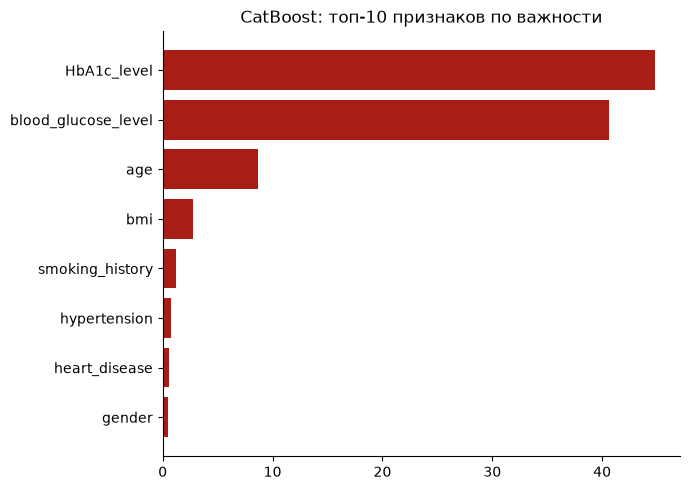

In [42]:
importances = pd.Series(cat.get_feature_importance(), index=X_tr_cb.columns).sort_values()
plt.figure(figsize=(7, 5))
plt.barh(importances.index[-10:], importances.values[-10:], color="#A81E17")
plt.title("CatBoost: топ-10 признаков по важности")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()

Хотим, чтобы среди пациентов, у которых есть диабет более 90% модель умела определять (recall >=0.90)

порог 0.103: recall 0.900, precision 0.524


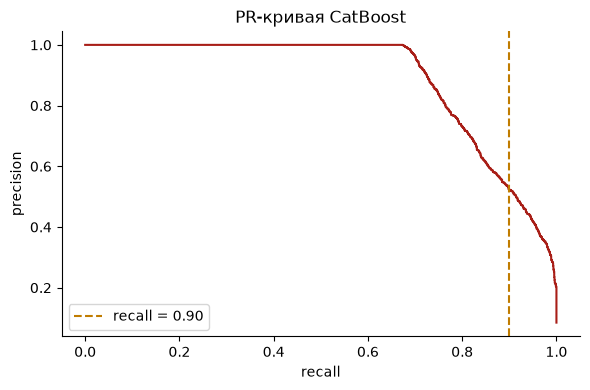

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, proba_cb)
mask = recall[:-1] >= 0.90
best_threshold = thresholds[mask].max()
pred = (proba_cb >= best_threshold).astype(int)
print(f"порог {best_threshold:.3f}: recall {recall_score(y_test, pred):.3f}, "
      f"precision {precision_score(y_test, pred):.3f}")

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, color="#A81E17")
plt.axvline(0.90, color="#C07C00", linestyle="--", label="recall = 0.90")
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("PR-кривая CatBoost")
plt.legend()
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()

In [44]:
precision.shape, recall.shape, thresholds.shape

((19308,), (19308,), (19307,))

In [45]:
import catboost
import sklearn

metadata = {
    "model_name": "diabets-baseline",
    "model_version": "0.1.0",
    "trained_at": pd.Timestamp.utcnow().isoformat(timespec="seconds"),
    "n_train": int(len(X_train)),
    "features": list(X.columns),
    "numeric_cols": numeric_cols,
    "categorical_cols": categorical_cols,
    "threshold": float(round(best_threshold, 4)),
    "metrics_test": {k: round(float(v), 4) for k, v in results[1].items() if k != "model"},
    "libs": {"pandas": pd.__version__, "scikit-learn": sklearn.__version__, "catboost": catboost.__version__},
}

joblib.dump({"pipeline": logreg, "metadata": {**metadata, "model_name": "churn-logreg"}},
            ARTIFACTS / "baseline_logreg.joblib")
cat.save_model(str(ARTIFACTS / "baseline_catboost.cbm"))
(ARTIFACTS / "metadata.json").write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")

sorted(p.name for p in ARTIFACTS.iterdir())

['baseline_catboost.cbm', 'baseline_logreg.joblib', 'metadata.json']

In [46]:
bundle = joblib.load(ARTIFACTS / "baseline_logreg.joblib")
pipe, meta = bundle["pipeline"], bundle["metadata"]

payload = X_test.iloc[0].to_dict()          # так придёт запрос: dict
#payload["TotalCharges"] = None if pd.isna(payload["TotalCharges"]) else payload["TotalCharges"]
frame = pd.DataFrame([payload])[meta["features"]]   # порядок колонок как при обучении

score = float(pipe.predict_proba(frame)[0, 1])
print(json.dumps({"score": round(score, 4),
                  "diabetes": bool(score >= meta["threshold"]),
                  "model_version": meta["model_version"]}, ensure_ascii=False))

{"score": 0.0156, "diabetes": false, "model_version": "0.1.0"}


In [47]:
pipe.predict_proba(frame)

array([[0.98440221, 0.01559779]])

In [48]:
pipe.predict_proba(frame)[0, 1]

np.float64(0.01559779423068151)

In [49]:
# контроль: предсказание на одной строке совпадает с предсказанием на всём батче
batch_score = pipe.predict_proba(X_test)[0, 1]
assert abs(batch_score - score) < 1e-9, "train-serve skew: одна строка и батч дают разные ответы"
print("одна строка и батч совпадают до 1e-9")

одна строка и батч совпадают до 1e-9
